In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt


In [7]:
df = pd.read_csv(r"C:\Users\jayal\Desktop\customer_summary.csv",sep=';')

In [8]:
df.columns = df.columns.str.strip()
df.head()

,Customer_id,customername,gender,age,total_purchases,total_spent,avg_purchase_value,churn
0,44605,John Rivera,Female,31,5,10755.0,2151.0000,0
1,13738,Lauren Johnson,Female,27,5,14483.0,2896.6000,0
2,33969,Carol Allen,Male,27,7,25266.0,3609.4286,0
3,42650,Curtis Smith,Female,20,13,35366.0,2720.4615,0
4,24053,Jose Green,Male,53,5,12253.0,2450.6000,0


In [9]:
x = df.drop(columns=['Customer_id','customername','churn'])
y = df['churn']

In [10]:
x = pd.get_dummies(x,drop_first=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [12]:
y_pred = dt.predict(x_test)

In [16]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nConfusion Matrix:",confusion_matrix(y_test,y_pred))

Accuracy: 0.6771653543307087

Confusion Matrix: [[82 19]
 [22  4]]


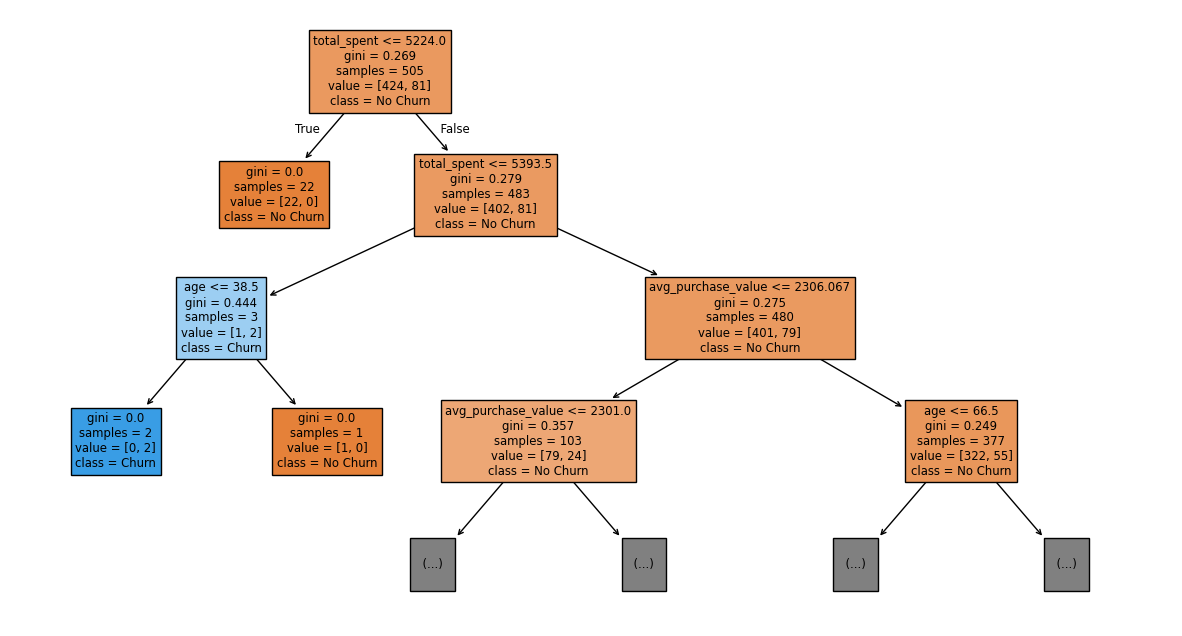

In [14]:
plt.figure(figsize=(15,8))
plot_tree(dt,feature_names=x.columns,class_names=['No Churn','Churn'],filled=True,max_depth=3)
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')

# Train model
rf.fit(x_train, y_train)

# Make predictions
y_pred_rf = rf.predict(x_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7952755905511811

Confusion Matrix:
 [[100   1]
 [ 25   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.99      0.88       101
           1       0.50      0.04      0.07        26

    accuracy                           0.80       127
   macro avg       0.65      0.51      0.48       127
weighted avg       0.74      0.80      0.72       127



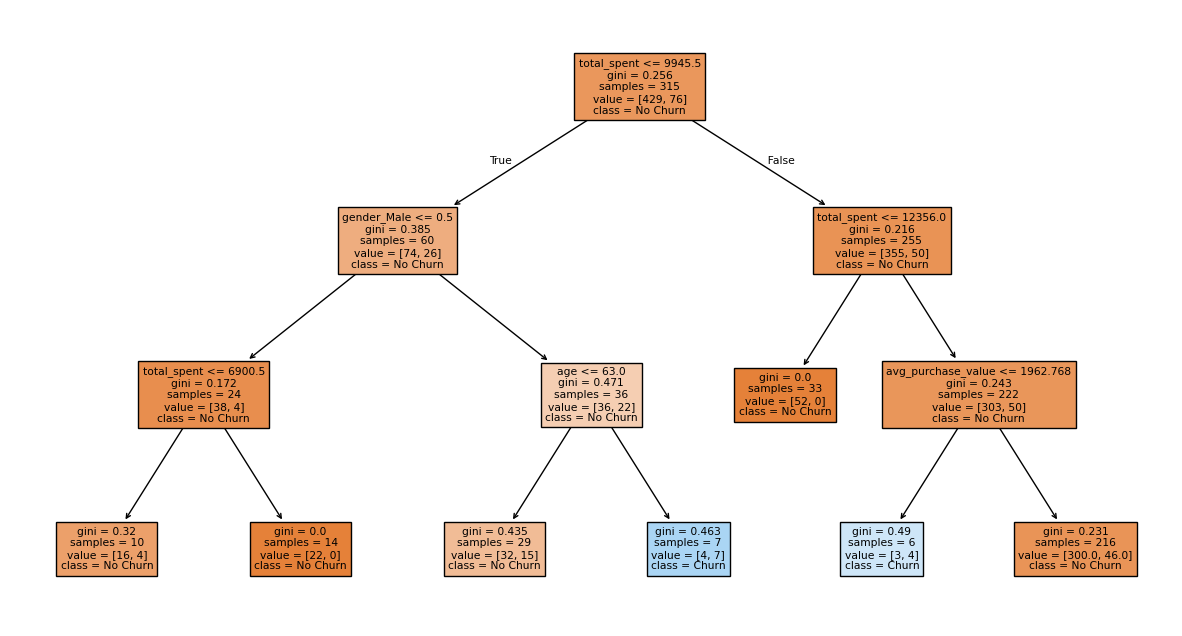

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Train Random Forest
rf = RandomForestClassifier(n_estimators=10, max_depth=3,random_state=42)
rf.fit(x_train, y_train)

# Select one tree from the forest
one_tree = rf.estimators_[0]

# Plot the tree
plt.figure(figsize=(15,8))
plot_tree(one_tree, 
          feature_names=x.columns, 
          class_names=['No Churn','Churn'], 
          filled=True)
plt.show()